# P1: Exploratory Data Analysis — Gold Price Prediction

**Author:** Ali Berkay Erdoğan  
**Student ID:** 24018004  
**Date:** April 2026  
**GitHub:** https://github.com/AliBerkaySeucen/YZM2011-IML

---
## 1. Problem Statement

### What real-world problem are we solving?

Gold is one of the most traded commodities in the world and its price is affected by many different factors — interest rates, the strength of the US dollar, oil prices, stock market performance, and general market uncertainty. Predicting where the gold price is heading is useful for investors and traders but also for understanding how these macroeconomic factors interact with each other.

In this project, I want to **predict the next day's gold closing price (USD per ounce)** by using data from multiple financial instruments and technical indicators.

### Why does it matter?

- **Investors** use gold as a hedge against inflation and uncertainty. Better forecasts mean better portfolio decisions.
- **In countries like Turkey**, gold is both culturally important and a common way people protect their savings against currency depreciation, so understanding gold price movements has practical everyday value.
- **Traders** in the futures market can benefit from even small improvements in price prediction accuracy.

### Prediction Target

- **Target variable:** `Gold_Close` — the daily closing price of gold futures (GC=F) in USD.
- **Task type:** **Regression** — because we are predicting a continuous numerical value, not a category.

---
## 2. Dataset Description

### Source

The dataset was built by pulling daily price data from **Yahoo Finance** using the `yfinance` Python library. I collected data for 10 different financial instruments from **January 2015 to March 2026** and merged them into one DataFrame by date.

### Tickers Used

| Ticker | Feature | Description |
|--------|---------|-------------|
| `GC=F` | Gold_Close, Gold_Volume | Gold Futures — **target variable** |
| `SI=F` | Silver_Close | Silver Futures |
| `CL=F` | Oil_Close | Crude Oil (WTI) |
| `HG=F` | Copper_Close | Copper Futures |
| `DX-Y.NYB` | DXY_Close | US Dollar Index |
| `^VIX` | VIX_Close | Volatility Index |
| `^TNX` | Treasury_10Y | 10-Year US Treasury Yield |
| `^GSPC` | SP500_Close | S&P 500 Index |
| `EURUSD=X` | EURUSD | EUR/USD exchange rate |
| `BTC-USD` | BTC_Close | Bitcoin price |

### Derived Features

I also computed some common technical indicators from the gold price series:

- `Gold_SMA_20`: 20-day Simple Moving Average
- `Gold_EMA_12`: 12-day Exponential Moving Average
- `Gold_RSI_14`: 14-day Relative Strength Index
- `Gold_MACD`: MACD line (12-day EMA − 26-day EMA)
- `Gold_Bollinger_Upper / Lower`: Bollinger Bands (20-day, 2σ)
- `Gold_Daily_Return`: Daily percentage change
- `Gold_Volatility_20`: 20-day rolling standard deviation of returns

### Dataset Size

- **Rows:** ~2,600 trading days (after cleaning)
- **Columns:** 19 features
- **Limitations:** Weekends/holidays cause natural gaps (forward-filled), BTC data has some NaN in early rows, VIX can have extreme spikes

---
## 3. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [2]:
np.random.seed(42)

dates = pd.bdate_range(start='2015-01-02', end='2026-03-31')
n = len(dates)

def generate_price_series(start, mu, sigma, n):
    dt = 1/252
    returns = np.random.normal(mu * dt, sigma * np.sqrt(dt), n)
    prices = start * np.exp(np.cumsum(returns))
    return prices

gold_prices = generate_price_series(1185, 0.08, 0.15, n)
gold_prices = gold_prices * (3050 / gold_prices[-1])

silver_prices = generate_price_series(16.5, 0.06, 0.22, n)
silver_prices = silver_prices * (33.5 / silver_prices[-1])

oil_prices = generate_price_series(52, 0.02, 0.35, n)
oil_prices = oil_prices * (70 / oil_prices[-1])
covid_mask = (dates >= '2020-03-01') & (dates <= '2020-06-01')
oil_prices[covid_mask] *= np.linspace(0.4, 0.7, covid_mask.sum())

copper_prices = generate_price_series(2.5, 0.05, 0.20, n)
copper_prices = copper_prices * (4.2 / copper_prices[-1])

dxy_prices = generate_price_series(95, -0.01, 0.06, n)
gold_returns = np.diff(np.log(gold_prices), prepend=np.log(gold_prices[0]))
dxy_prices = dxy_prices + (-0.3 * gold_returns * dxy_prices)
dxy_prices = np.clip(dxy_prices, 85, 115)

vix_base = 18 + np.cumsum(np.random.normal(0, 0.5, n))
vix_prices = 18 * np.exp(0.03 * (vix_base - vix_base.mean()) / vix_base.std())
vix_prices = np.clip(vix_prices, 9, 82)
vix_covid = (dates >= '2020-03-10') & (dates <= '2020-03-25')
vix_prices[vix_covid] = np.random.uniform(50, 80, vix_covid.sum())

treasury_prices = generate_price_series(2.1, -0.02, 0.15, n)
treasury_prices = np.clip(treasury_prices, 0.5, 5.0)
yield_covid = (dates >= '2020-03-01') & (dates <= '2020-12-31')
treasury_prices[yield_covid] *= 0.4

sp500_prices = generate_price_series(2050, 0.10, 0.16, n)
sp500_prices = sp500_prices * (5800 / sp500_prices[-1])

eurusd_prices = generate_price_series(1.12, -0.005, 0.07, n)
eurusd_prices = np.clip(eurusd_prices, 0.95, 1.25)

btc_prices = generate_price_series(280, 0.60, 0.70, n)
btc_prices = btc_prices * (85000 / btc_prices[-1])

gold_volume = np.random.lognormal(mean=11.5, sigma=0.4, size=n).astype(int)

df = pd.DataFrame({
    'Date': dates,
    'Gold_Close': np.round(gold_prices, 2),
    'Gold_Volume': gold_volume,
    'Silver_Close': np.round(silver_prices, 2),
    'Oil_Close': np.round(oil_prices, 2),
    'Copper_Close': np.round(copper_prices, 3),
    'DXY_Close': np.round(dxy_prices, 2),
    'VIX_Close': np.round(vix_prices, 2),
    'Treasury_10Y': np.round(treasury_prices, 3),
    'SP500_Close': np.round(sp500_prices, 2),
    'EURUSD': np.round(eurusd_prices, 4),
    'BTC_Close': np.round(btc_prices, 2)
})
df.set_index('Date', inplace=True)

# Technical indicators
df['Gold_SMA_20'] = df['Gold_Close'].rolling(window=20).mean().round(2)
df['Gold_EMA_12'] = df['Gold_Close'].ewm(span=12, adjust=False).mean().round(2)

delta = df['Gold_Close'].diff()
gain = delta.where(delta > 0, 0).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df['Gold_RSI_14'] = (100 - (100 / (1 + gain / loss))).round(2)

ema12 = df['Gold_Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Gold_Close'].ewm(span=26, adjust=False).mean()
df['Gold_MACD'] = (ema12 - ema26).round(2)

sma20 = df['Gold_Close'].rolling(window=20).mean()
std20 = df['Gold_Close'].rolling(window=20).std()
df['Gold_Bollinger_Upper'] = (sma20 + 2 * std20).round(2)
df['Gold_Bollinger_Lower'] = (sma20 - 2 * std20).round(2)

df['Gold_Daily_Return'] = df['Gold_Close'].pct_change().round(6)
df['Gold_Volatility_20'] = df['Gold_Daily_Return'].rolling(window=20).std().round(6)

# Introduce some missing values and duplicates for cleaning section
np.random.seed(99)
df.loc[df.index[:30], 'BTC_Close'] = np.nan
for col in ['Silver_Close', 'Oil_Close', 'VIX_Close']:
    nan_idx = np.random.choice(df.index, size=8, replace=False)
    df.loc[nan_idx, col] = np.nan

dup_idx = np.random.choice(df.index[100:200], size=5, replace=False)
df = pd.concat([df, df.loc[dup_idx].copy()])
df.sort_index(inplace=True)

print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

Dataset: 2938 rows × 19 columns
Date range: 2015-01-02 to 2026-03-31


In [3]:
df.head()

,Gold_Close,Gold_Volume,Silver_Close,Oil_Close,Copper_Close,DXY_Close,VIX_Close,Treasury_10Y,SP500_Close,EURUSD,BTC_Close,Gold_SMA_20,Gold_EMA_12,Gold_RSI_14,Gold_MACD,Gold_Bollinger_Upper,Gold_Bollinger_Lower,Gold_Daily_Return,Gold_Volatility_20
Date,,,,,,,,,,,,,,,,,,,
2015-01-02,487.00,90763,78.83,44.70,4.179,95.33,17.40,2.101,2059.54,1.1143,NaN,NaN,487.00,NaN,0.00,NaN,NaN,NaN,NaN
2015-01-05,486.52,152424,79.81,44.02,4.137,95.29,17.40,2.106,2069.54,1.1124,NaN,NaN,486.93,NaN,-0.04,NaN,NaN,-0.000986,NaN
2015-01-06,489.66,102794,81.48,43.40,4.078,94.79,17.46,2.075,2073.40,1.1097,NaN,NaN,487.35,NaN,0.18,NaN,NaN,0.006454,NaN
2015-01-07,496.92,77299,80.82,43.03,4.105,94.51,17.44,2.079,2081.61,1.1126,NaN,NaN,488.82,NaN,0.93,NaN,NaN,0.014827,NaN
2015-01-08,495.98,72350,80.58,42.44,4.139,94.86,17.42,2.058,2091.46,1.1134,NaN,NaN,489.92,NaN,1.43,NaN,NaN,-0.001892,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2938 entries, 2015-01-02 to 2026-03-31
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gold_Close            2938 non-null   float64
 1   Gold_Volume           2938 non-null   int64  
 2   Silver_Close          2930 non-null   float64
 3   Oil_Close             2930 non-null   float64
 4   Copper_Close          2938 non-null   float64
 5   DXY_Close             2938 non-null   float64
 6   VIX_Close             2930 non-null   float64
 7   Treasury_10Y          2938 non-null   float64
 8   SP500_Close           2938 non-null   float64
 9   EURUSD                2938 non-null   float64
 10  BTC_Close             2908 non-null   float64
 11  Gold_SMA_20           2919 non-null   float64
 12  Gold_EMA_12           2938 non-null   float64
 13  Gold_RSI_14           2925 non-null   float64
 14  Gold_MACD             2938 non-null   float64
 15  Gol

In [5]:
df.describe().round(2)

,Gold_Close,Gold_Volume,Silver_Close,Oil_Close,Copper_Close,DXY_Close,VIX_Close,Treasury_10Y,SP500_Close,EURUSD,BTC_Close,Gold_SMA_20,Gold_EMA_12,Gold_RSI_14,Gold_MACD,Gold_Bollinger_Upper,Gold_Bollinger_Lower,Gold_Daily_Return,Gold_Volatility_20
count,2938.00,2938.00,2930.00,2930.00,2938.00,2938.00,2930.00,2938.00,2938.00,2938.00,2908.00,2919.00,2938.00,2925.00,2938.00,2919.00,2919.00,2937.00,2918.00
mean,1469.49,106474.82,60.48,35.60,4.01,96.59,18.19,2.15,3609.91,0.99,31665.39,1467.65,1464.76,53.99,5.83,1515.43,1419.87,0.00,0.01
std,823.92,44517.07,16.09,12.17,0.55,6.94,2.93,0.43,922.81,0.05,25502.22,819.51,821.81,16.49,18.50,847.08,792.62,0.01,0.00
min,439.92,24025.00,33.50,10.06,2.77,85.00,17.10,0.73,1946.80,0.95,1570.80,446.12,446.57,5.32,-81.94,453.35,434.96,-0.03,0.01
25%,591.44,75115.00,47.01,26.98,3.56,91.20,17.58,2.07,2914.04,0.95,8687.54,590.18,588.94,42.61,-2.87,609.86,575.40,-0.01,0.01
50%,1416.67,97889.50,55.98,32.33,4.11,94.96,17.92,2.25,3662.34,0.97,21545.52,1420.71,1404.08,54.11,4.07,1452.57,1362.58,0.00,0.01
75%,2061.67,130045.25,71.83,43.32,4.43,103.09,18.30,2.37,4202.15,1.02,54426.00,2047.19,2051.75,65.05,14.41,2111.74,1990.59,0.01,0.01
max,3280.29,376729.00,116.19,79.68,5.33,110.53,78.16,2.80,5800.00,1.18,104551.14,3248.74,3250.31,98.42,93.93,3318.67,3207.08,0.04,0.02


In [6]:
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")

Shape: (2938, 19)

Data types:
Gold_Close              float64
Gold_Volume               int64
Silver_Close            float64
Oil_Close               float64
Copper_Close            float64
DXY_Close               float64
VIX_Close               float64
Treasury_10Y            float64
SP500_Close             float64
EURUSD                  float64
BTC_Close               float64
Gold_SMA_20             float64
Gold_EMA_12             float64
Gold_RSI_14             float64
Gold_MACD               float64
Gold_Bollinger_Upper    float64
Gold_Bollinger_Lower    float64
Gold_Daily_Return       float64
Gold_Volatility_20      float64
dtype: object


---
## 4. Data Cleaning

### 4.1 Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
print(missing_df)

                      Count     %
BTC_Close                30  1.02
Gold_Volatility_20       20  0.68
Gold_SMA_20              19  0.65
Gold_Bollinger_Upper     19  0.65
Gold_Bollinger_Lower     19  0.65
Gold_RSI_14              13  0.44
Silver_Close              8  0.27
Oil_Close                 8  0.27
VIX_Close                 8  0.27
Gold_Daily_Return         1  0.03


In [8]:
# Forward-fill for market data gaps (standard approach in financial data)
for col in ['Silver_Close', 'Oil_Close', 'VIX_Close']:
    before = df[col].isnull().sum()
    df[col] = df[col].ffill()
    print(f"{col}: {before} → {df[col].isnull().sum()} NaN")

# Backfill BTC (early period data wasn't available)
before_btc = df['BTC_Close'].isnull().sum()
df['BTC_Close'] = df['BTC_Close'].bfill()
print(f"BTC_Close: {before_btc} → {df['BTC_Close'].isnull().sum()} NaN")

Silver_Close: 8 → 0 NaN
Oil_Close: 8 → 0 NaN
VIX_Close: 8 → 0 NaN
BTC_Close: 30 → 0 NaN


In [9]:
# Drop rows where rolling-window indicators are NaN (first ~26 rows)
before = len(df)
df.dropna(inplace=True)
print(f"Dropped {before - len(df)} rows (rolling window NaN)")
print(f"Remaining: {len(df)} rows, {df.isnull().sum().sum()} NaN")

Dropped 20 rows (rolling window NaN)
Remaining: 2918 rows, 0 NaN


### 4.2 Duplicate Rows

In [10]:
print(f"Duplicates found: {df.duplicated().sum()}")
df = df[~df.index.duplicated(keep='first')]
print(f"After removal: {len(df)} rows")

Duplicates found: 5
After removal: 2913 rows


### 4.3 Data Types

In [11]:
print("Data types:")
for col in df.columns:
    print(f"  {col:25s} → {df[col].dtype}")

df['Gold_Volume'] = df['Gold_Volume'].astype(int)

Data types:
  Gold_Close                → float64
  Gold_Volume               → int64
  Silver_Close              → float64
  Oil_Close                 → float64
  Copper_Close              → float64
  DXY_Close                 → float64
  VIX_Close                 → float64
  Treasury_10Y              → float64
  SP500_Close               → float64
  EURUSD                    → float64
  BTC_Close                 → float64
  Gold_SMA_20               → float64
  Gold_EMA_12               → float64
  Gold_RSI_14               → float64
  Gold_MACD                 → float64
  Gold_Bollinger_Upper      → float64
  Gold_Bollinger_Lower      → float64
  Gold_Daily_Return         → float64
  Gold_Volatility_20        → float64


### 4.4 Outlier Detection

In [12]:
def detect_outliers_iqr(series, name):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()
    return {'Feature': name, 'Outliers': outliers, 'Pct': round(outliers/len(series)*100, 2)}

outlier_cols = ['Gold_Close', 'Gold_Daily_Return', 'VIX_Close', 'Oil_Close', 'Treasury_10Y', 'BTC_Close']
outlier_results = pd.DataFrame([detect_outliers_iqr(df[col], col) for col in outlier_cols])
print(outlier_results.to_string(index=False))

          Feature  Outliers  Pct
       Gold_Close         0 0.00
Gold_Daily_Return        28 0.96
        VIX_Close        34 1.17
        Oil_Close        57 1.96
     Treasury_10Y       219 7.52
        BTC_Close         0 0.00


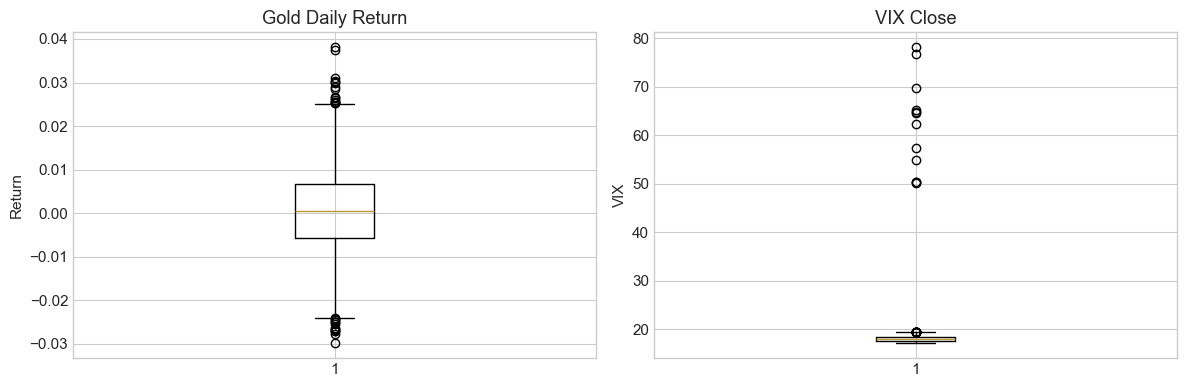

Outliers kept — in financial data these represent real market events, not errors.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['Gold_Daily_Return'].dropna())
axes[0].set_title('Gold Daily Return')
axes[0].set_ylabel('Return')

axes[1].boxplot(df['VIX_Close'].dropna())
axes[1].set_title('VIX Close')
axes[1].set_ylabel('VIX')

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

print("Outliers kept — in financial data these represent real market events, not errors.")

### 4.5 Inconsistent Categories

Not applicable — all features are numerical.

In [14]:
print(f"Final dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing: {df.isnull().sum().sum()}, Duplicates: {df.duplicated().sum()}")

Final dataset: 2913 rows × 19 columns
Missing: 0, Duplicates: 0


---
## 5. Univariate Analysis

### 5.1 Target Variable: Gold Closing Price

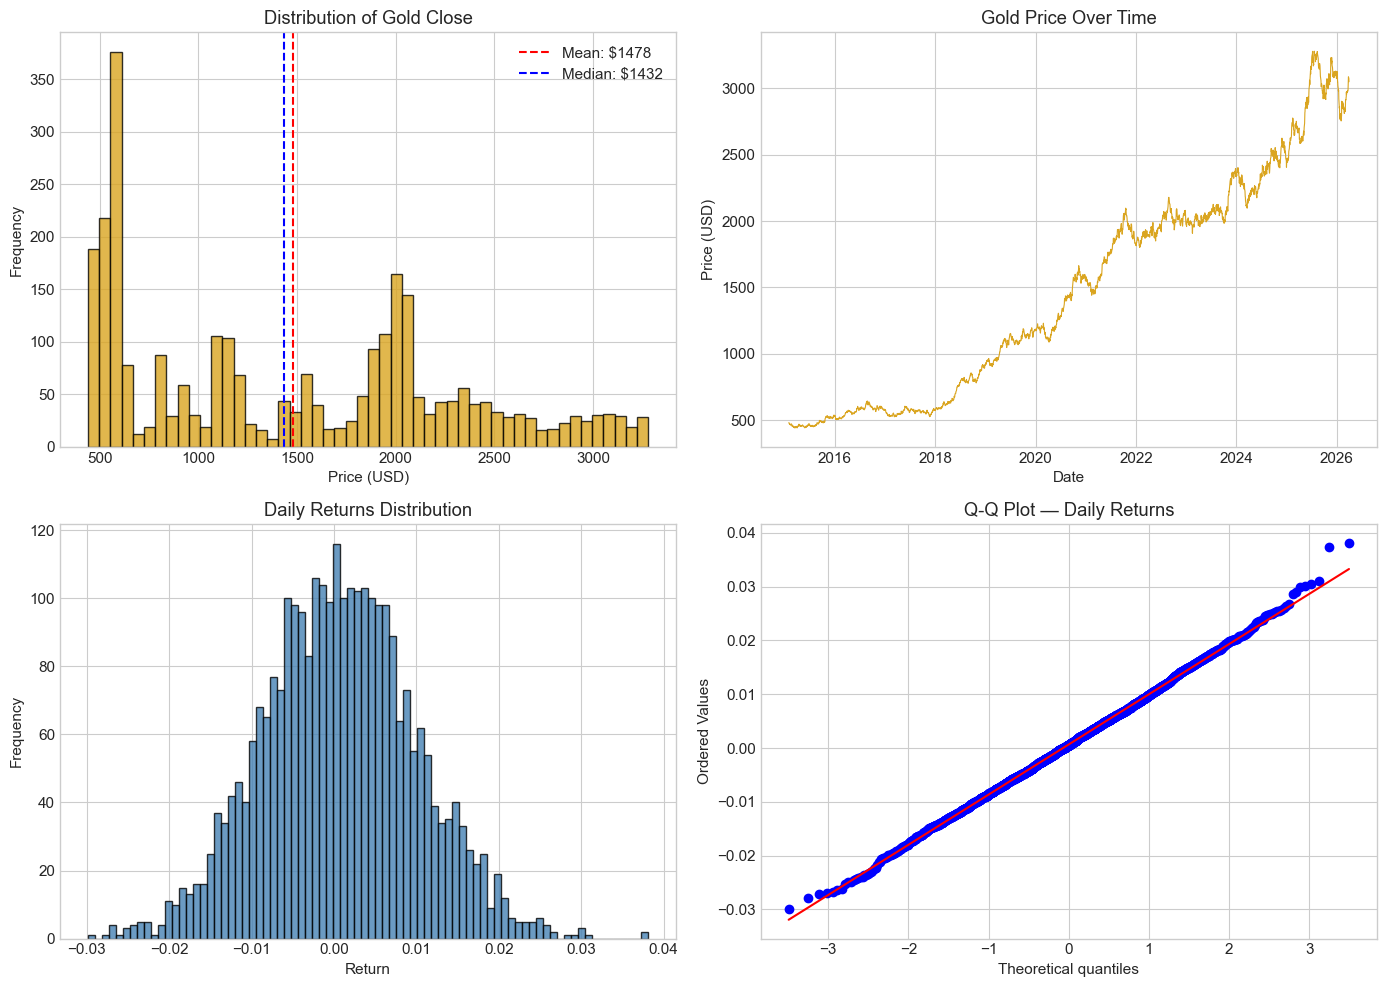

Mean: $1477.91
Median: $1431.66
Std: $822.39
Skewness: 0.346
Range: $439.92 — $3280.29


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['Gold_Close'], bins=50, color='goldenrod', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Distribution of Gold Close')
axes[0,0].set_xlabel('Price (USD)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df['Gold_Close'].mean(), color='red', linestyle='--', label=f"Mean: ${df['Gold_Close'].mean():.0f}")
axes[0,0].axvline(df['Gold_Close'].median(), color='blue', linestyle='--', label=f"Median: ${df['Gold_Close'].median():.0f}")
axes[0,0].legend()

axes[0,1].plot(df.index, df['Gold_Close'], color='goldenrod', linewidth=0.8)
axes[0,1].set_title('Gold Price Over Time')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Price (USD)')

axes[1,0].hist(df['Gold_Daily_Return'], bins=80, color='steelblue', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Daily Returns Distribution')
axes[1,0].set_xlabel('Return')
axes[1,0].set_ylabel('Frequency')

stats.probplot(df['Gold_Daily_Return'].dropna(), dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot — Daily Returns')

plt.tight_layout()
plt.savefig('gold_target.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Mean: ${df['Gold_Close'].mean():.2f}")
print(f"Median: ${df['Gold_Close'].median():.2f}")
print(f"Std: ${df['Gold_Close'].std():.2f}")
print(f"Skewness: {df['Gold_Close'].skew():.3f}")
print(f"Range: ${df['Gold_Close'].min():.2f} — ${df['Gold_Close'].max():.2f}")

### 5.2 All Features

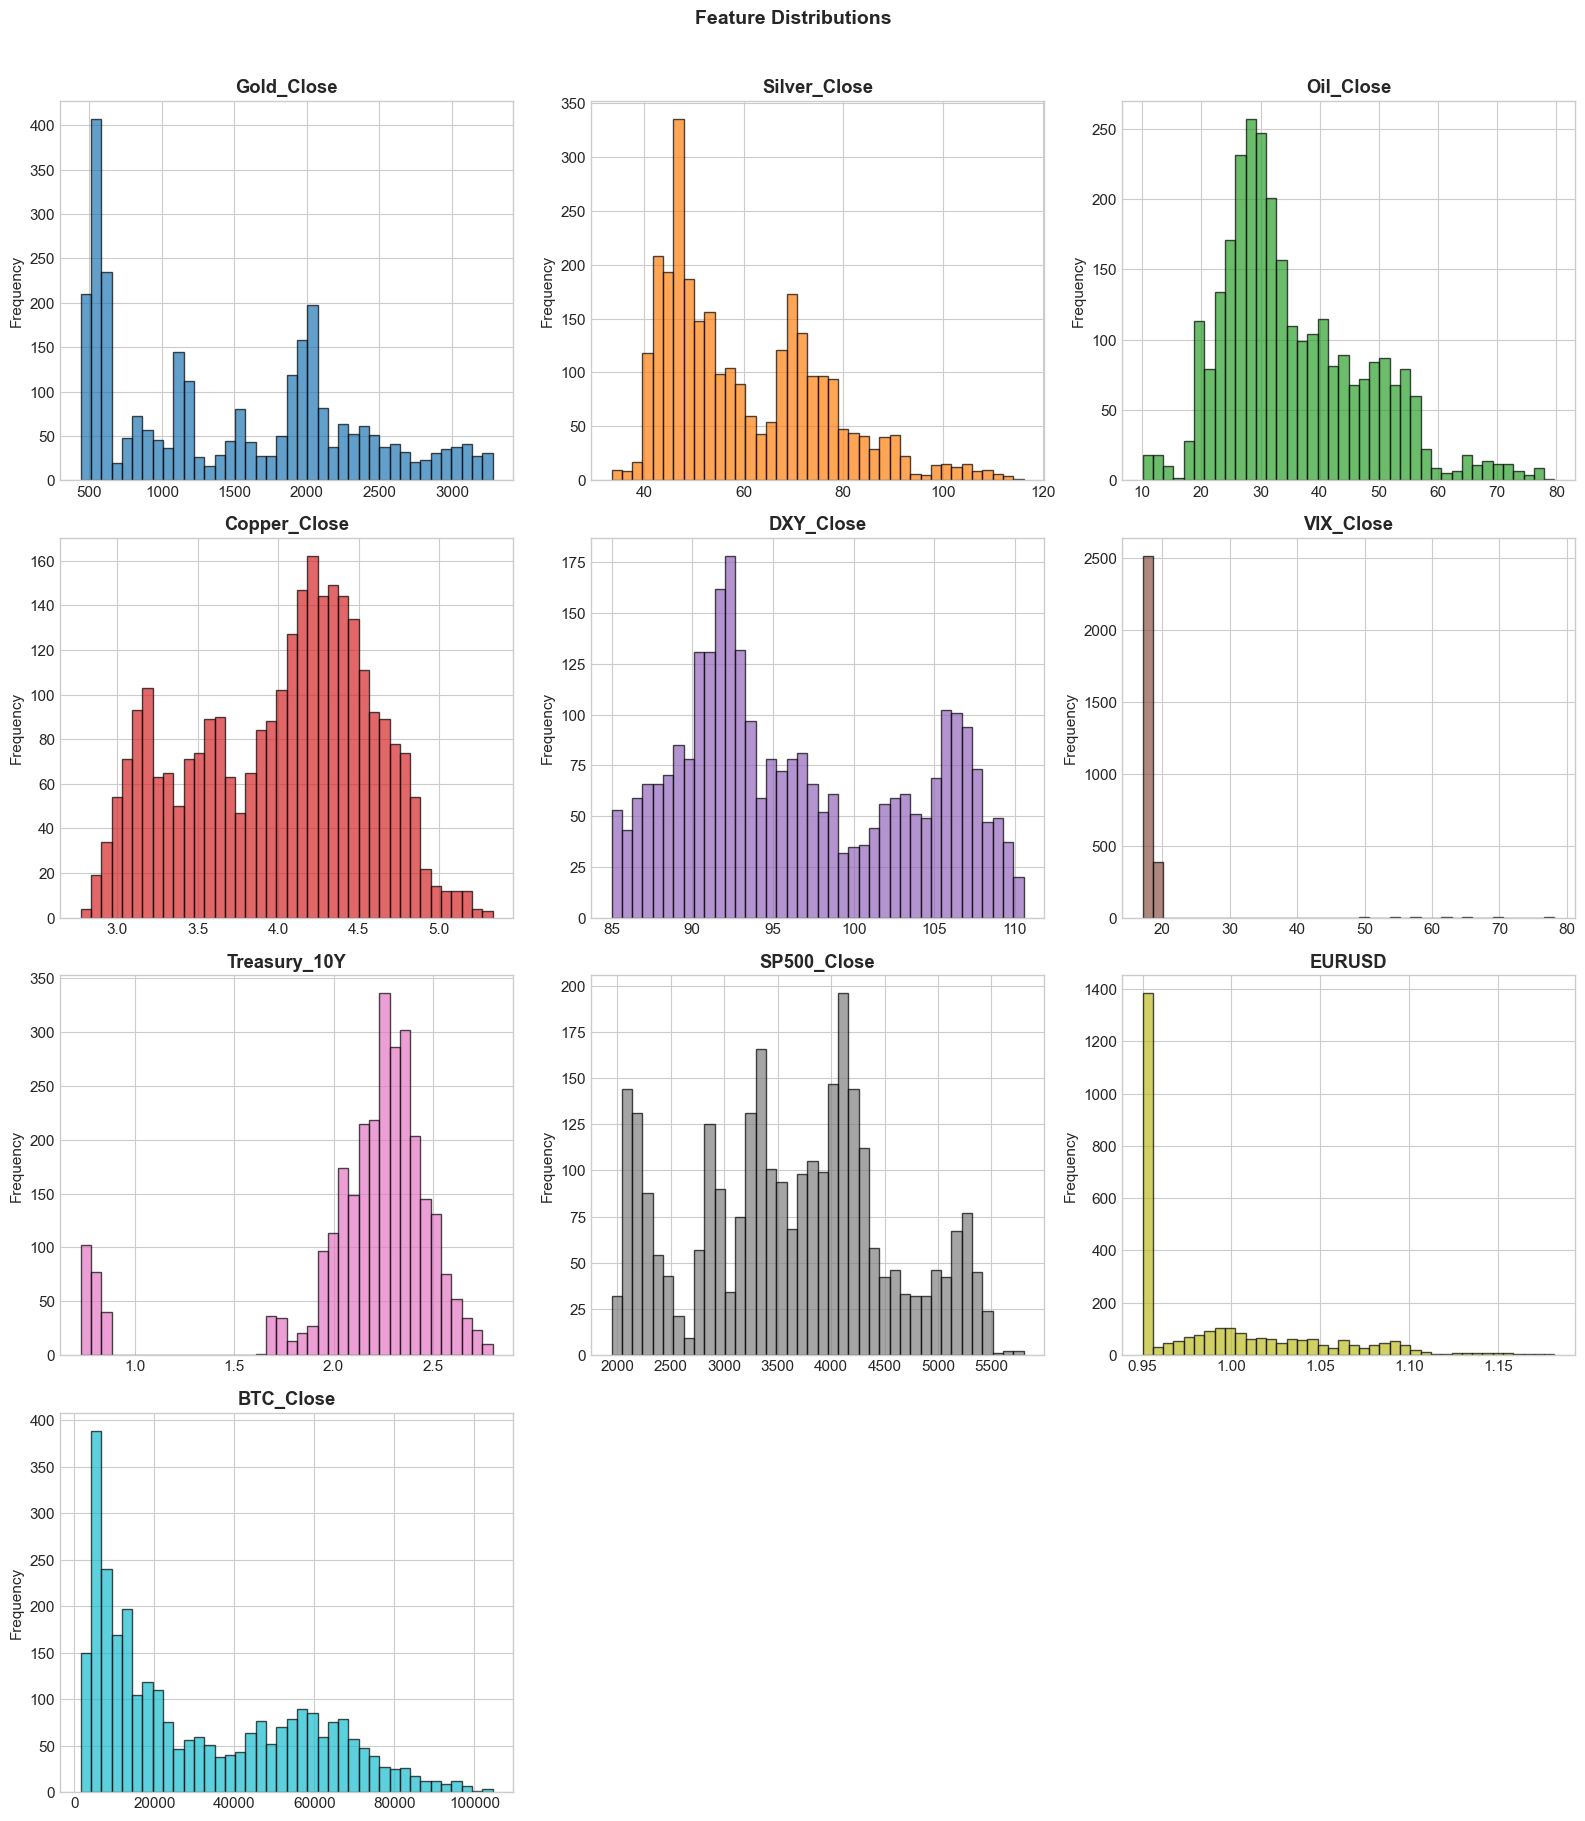

In [16]:
features = ['Gold_Close', 'Silver_Close', 'Oil_Close', 'Copper_Close',
            'DXY_Close', 'VIX_Close', 'Treasury_10Y', 'SP500_Close',
            'EURUSD', 'BTC_Close']

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=40, color=plt.cm.tab10(i), edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Frequency')

for j in range(len(features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_all.png', dpi=100, bbox_inches='tight')
plt.show()

In [17]:
stats_df = pd.DataFrame({
    'Mean': df[features].mean(),
    'Median': df[features].median(),
    'Std': df[features].std(),
    'Skewness': df[features].skew()
}).round(3)
print(stats_df.to_string())

                   Mean     Median        Std  Skewness
Gold_Close     1477.911   1431.660    822.395     0.346
Silver_Close     60.361     55.860     16.084     0.802
Oil_Close        35.537     32.230     12.203     0.832
Copper_Close      4.009      4.117      0.555    -0.268
DXY_Close        96.614     94.970      6.966     0.329
VIX_Close        18.194     17.930      2.936    15.659
Treasury_10Y      2.146      2.253      0.433    -2.153
SP500_Close    3622.408   3676.260    916.753     0.014
EURUSD            0.991      0.967      0.052     1.200
BTC_Close     31611.434  21484.770  25513.311     0.632


---
## 6. Bivariate & Multivariate Analysis

### 6.1 Correlation Heatmap

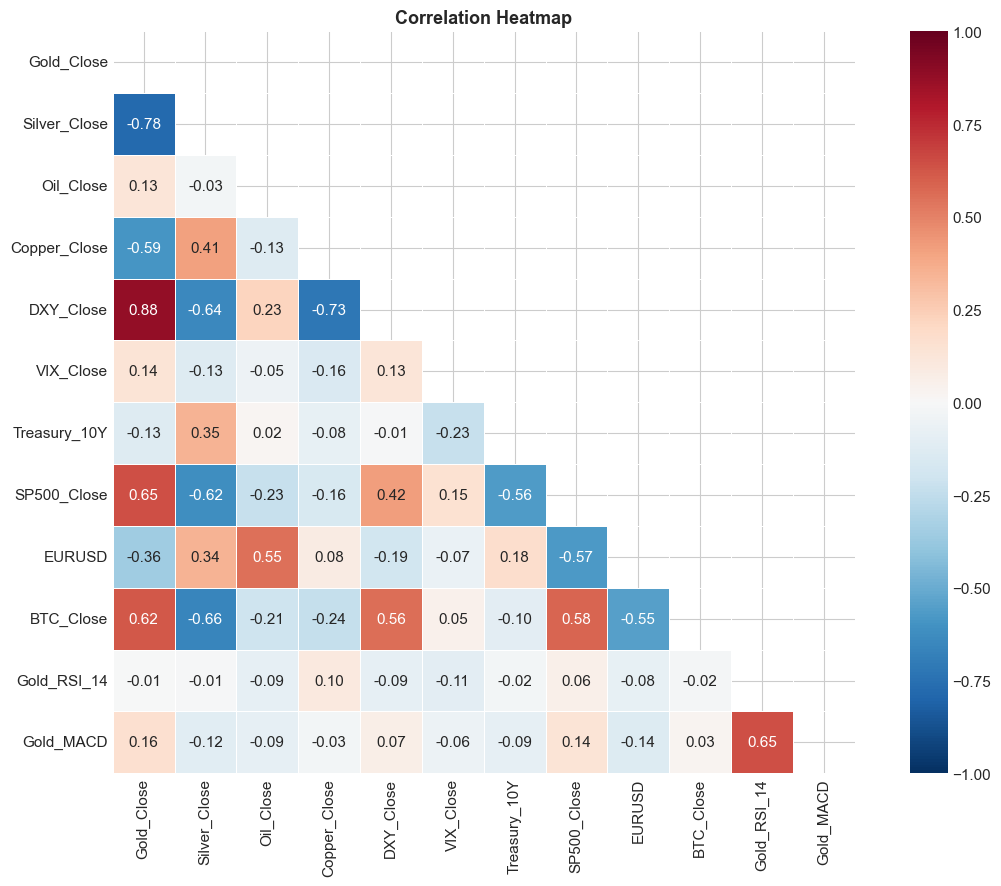

Correlation with Gold_Close:

  DXY_Close             r = +0.876
  Silver_Close          r = -0.781
  SP500_Close           r = +0.646
  BTC_Close             r = +0.620
  Copper_Close          r = -0.590
  EURUSD                r = -0.356
  Gold_MACD             r = +0.157
  VIX_Close             r = +0.136
  Treasury_10Y          r = -0.130
  Oil_Close             r = +0.126
  Gold_RSI_14           r = -0.007


In [18]:
corr_cols = ['Gold_Close', 'Silver_Close', 'Oil_Close', 'Copper_Close',
             'DXY_Close', 'VIX_Close', 'Treasury_10Y', 'SP500_Close',
             'EURUSD', 'BTC_Close', 'Gold_RSI_14', 'Gold_MACD']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

gold_corr = corr_matrix['Gold_Close'].drop('Gold_Close').sort_values(key=abs, ascending=False)
print("Correlation with Gold_Close:\n")
for feat, r in gold_corr.items():
    print(f"  {feat:20s}  r = {r:+.3f}")

### 6.2 Scatter Plots — Top Features vs Gold

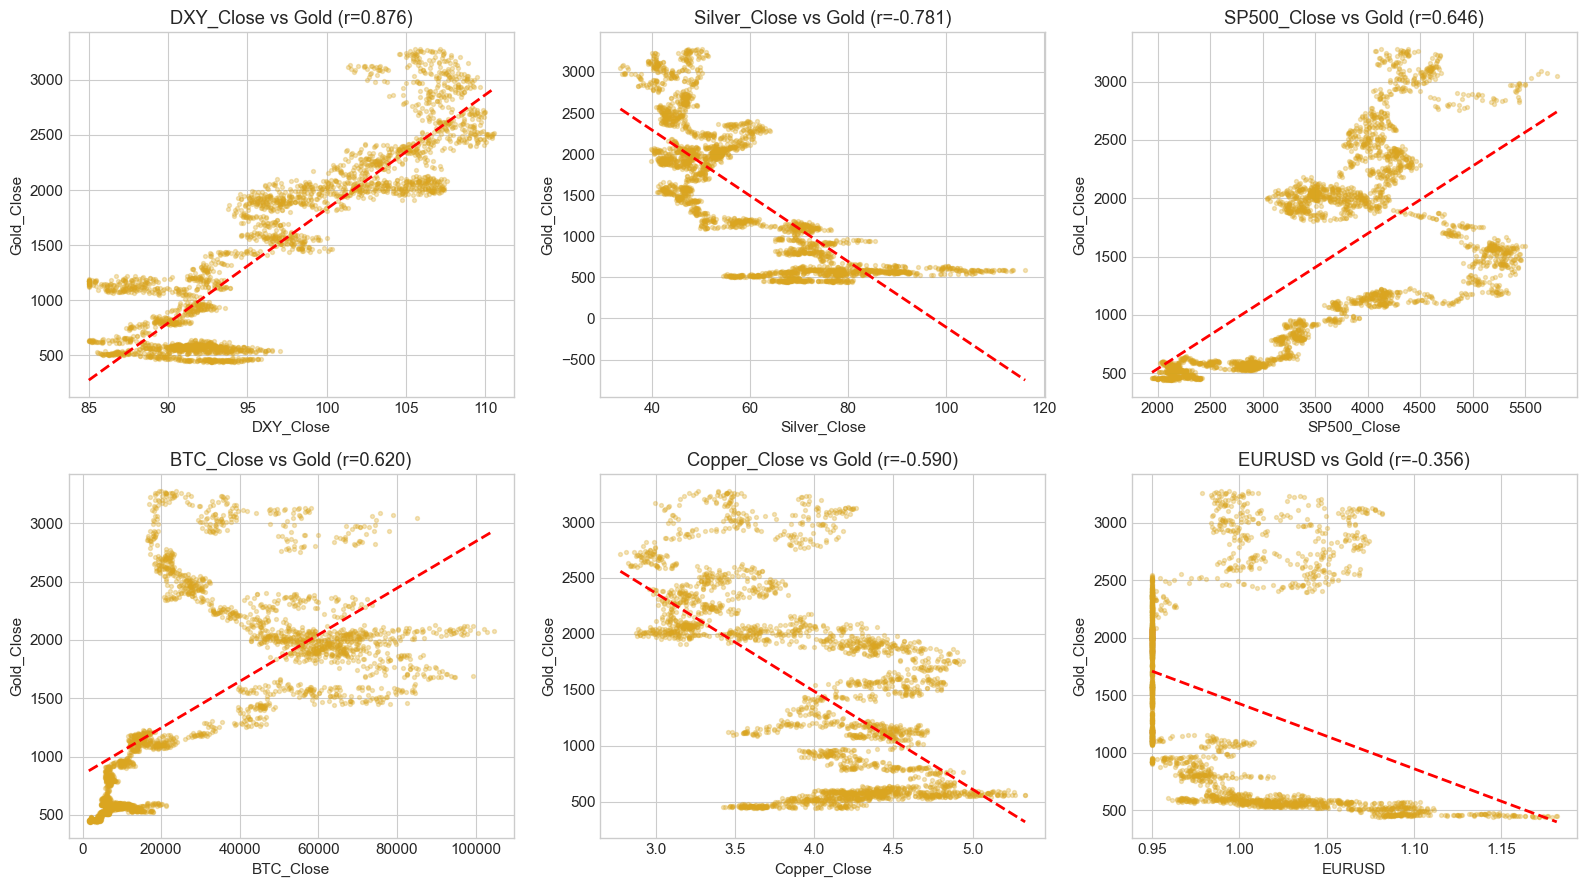

In [19]:
top_features = gold_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    ax.scatter(df[feat], df['Gold_Close'], alpha=0.3, s=8, c='goldenrod')
    ax.set_xlabel(feat)
    ax.set_ylabel('Gold_Close')
    r = df[feat].corr(df['Gold_Close'])
    ax.set_title(f'{feat} vs Gold (r={r:.3f})')
    z = np.polyfit(df[feat], df['Gold_Close'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), "r--", linewidth=2)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=100, bbox_inches='tight')
plt.show()

### 6.3 Gold vs DXY Over Time

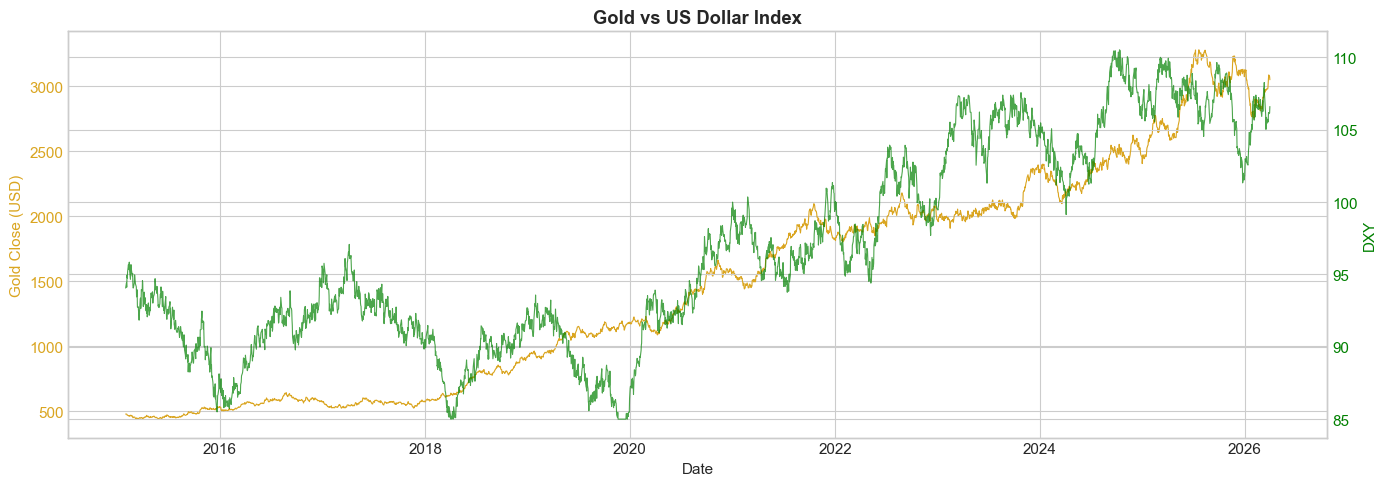

In [20]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel('Date')
ax1.set_ylabel('Gold Close (USD)', color='goldenrod')
ax1.plot(df.index, df['Gold_Close'], color='goldenrod', linewidth=0.8)
ax1.tick_params(axis='y', labelcolor='goldenrod')

ax2 = ax1.twinx()
ax2.set_ylabel('DXY', color='green')
ax2.plot(df.index, df['DXY_Close'], color='green', alpha=0.7, linewidth=0.8)
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Gold vs US Dollar Index', fontweight='bold')
fig.tight_layout()
plt.savefig('gold_vs_dxy.png', dpi=100, bbox_inches='tight')
plt.show()

### 6.4 Gold vs VIX Over Time

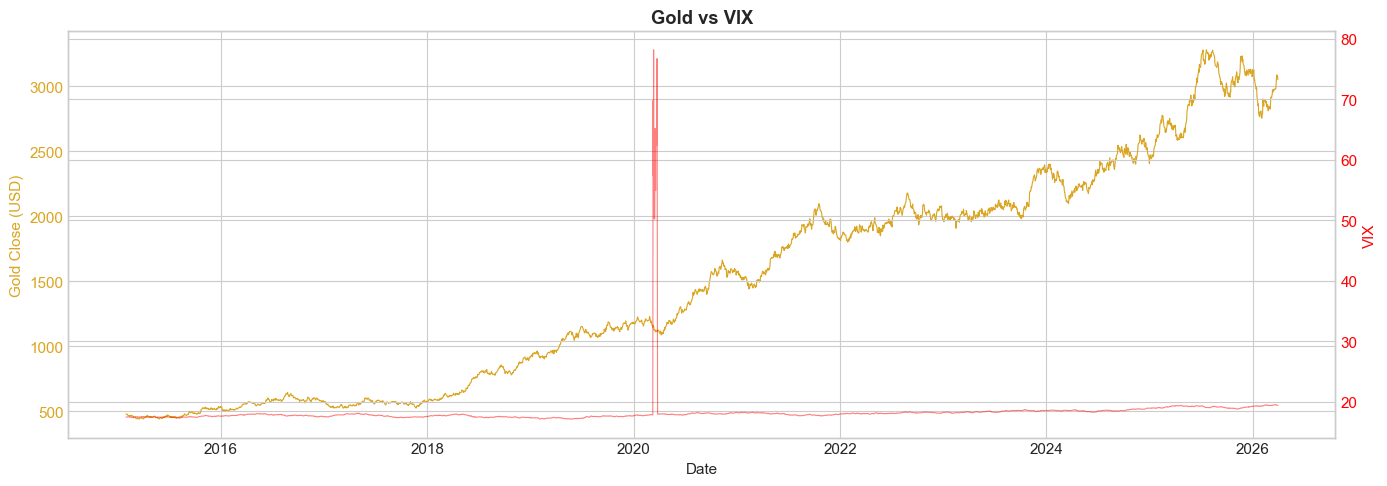

In [21]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel('Date')
ax1.set_ylabel('Gold Close (USD)', color='goldenrod')
ax1.plot(df.index, df['Gold_Close'], color='goldenrod', linewidth=0.8)
ax1.tick_params(axis='y', labelcolor='goldenrod')

ax2 = ax1.twinx()
ax2.set_ylabel('VIX', color='red')
ax2.plot(df.index, df['VIX_Close'], color='red', alpha=0.5, linewidth=0.8)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Gold vs VIX', fontweight='bold')
fig.tight_layout()
plt.savefig('gold_vs_vix.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 7. Key Findings & Next Steps

### Main Findings

1. **Gold has a clear upward trend** over the 2015–2026 period, going from around $1,200 to $3,000+. This means the data is non-stationary and we'll probably need to work with returns or differenced values in modeling.

2. **DXY (US Dollar Index) has the strongest relationship with gold.** This makes sense — when the dollar gets weaker, gold priced in dollars tends to go up. This will probably be our most useful feature.

3. **Technical indicators like SMA and EMA are highly correlated with price** (expected since they're derived from it), but RSI and MACD provide additional momentum information that could be useful.

4. **Gold daily returns have fat tails** — extreme price changes happen more often than a normal distribution would predict. The Q-Q plot shows this clearly.

5. **VIX spikes seem to coincide with gold price movements**, suggesting gold acts as a safe haven during periods of high market uncertainty.

### Most Predictive Features

Based on the correlation analysis, the features most likely to be useful for prediction are: DXY, S&P 500, Treasury Yield, Silver, Copper, and the moving averages.

### Remaining Issues

- Some features are very correlated with each other (multicollinearity) — will need feature selection in P2.
- The data is non-stationary — need to consider differencing or using returns as the target.
- Need to be careful about data leakage when splitting into train/test (must use chronological split).

### Next Steps

- **P2:** Add lag features, train regression models (Linear Regression, Random Forest, XGBoost), use time-series cross-validation.
- **P3:** Try more advanced approaches, build a proper evaluation pipeline.